Step 1: Generating synthetic dataset...
Dataset generated with 2000 rows and 11 columns.
------------------------------
Step 2: Performing Exploratory Data Analysis (EDA)...


/tmp/ipython-input-3099864837.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=self.df, palette='viridis')


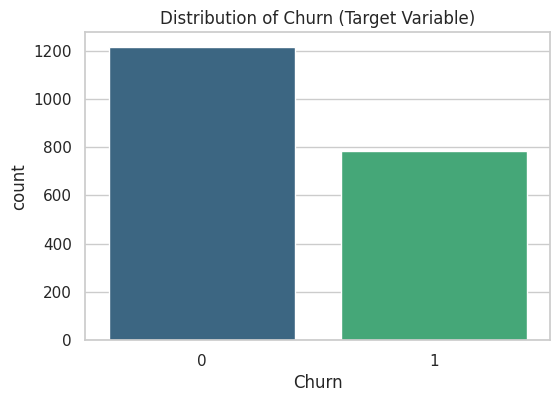

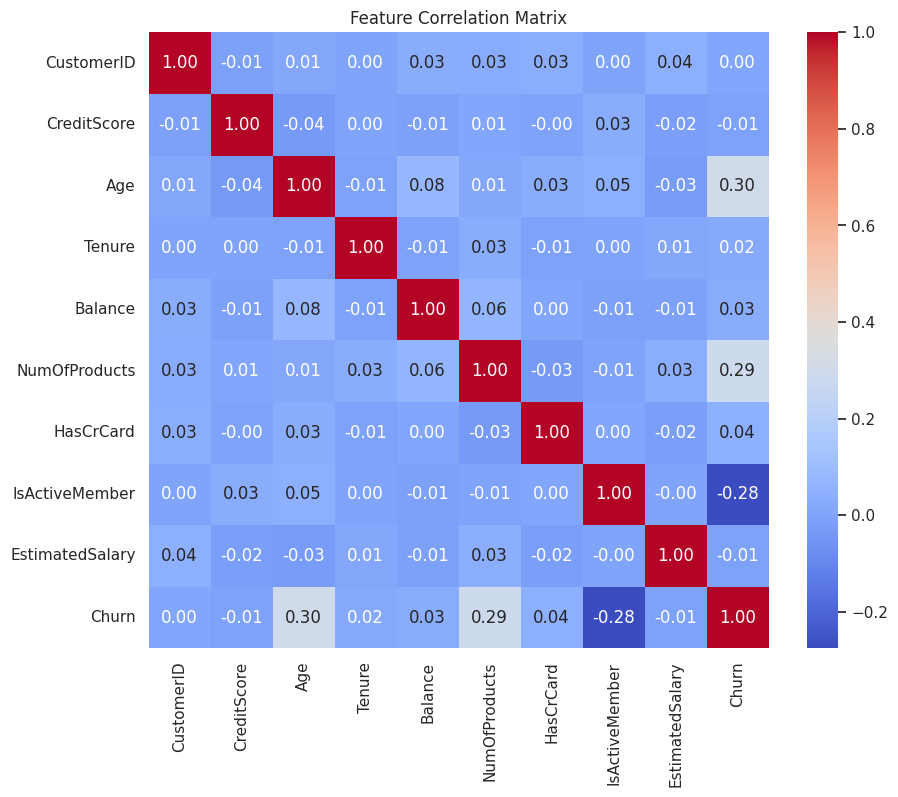

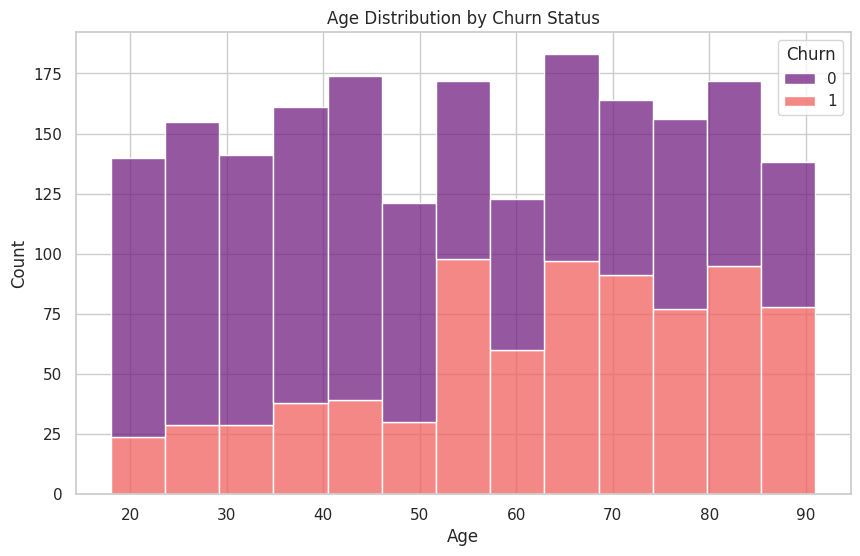

EDA Visualizations displayed.
------------------------------
Step 3: Preprocessing data...
Data preprocessed and split into Train/Test sets.
------------------------------
Step 4: Training Random Forest Model...
Model training complete.
------------------------------
Step 5: Evaluating Model...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       237
           1       0.75      0.65      0.70       163

    accuracy                           0.77       400
   macro avg       0.77      0.75      0.76       400
weighted avg       0.77      0.77      0.77       400



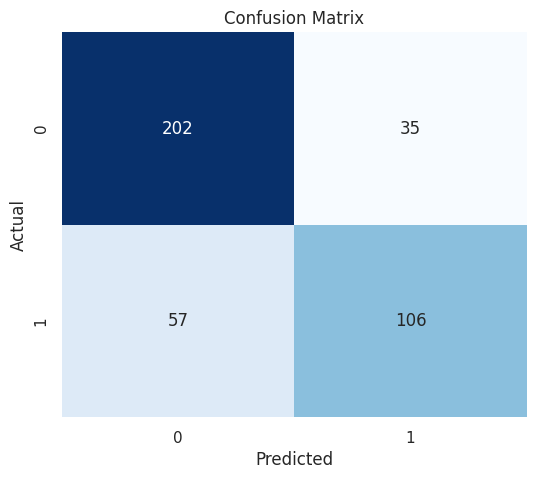

ROC-AUC Score: 0.8252


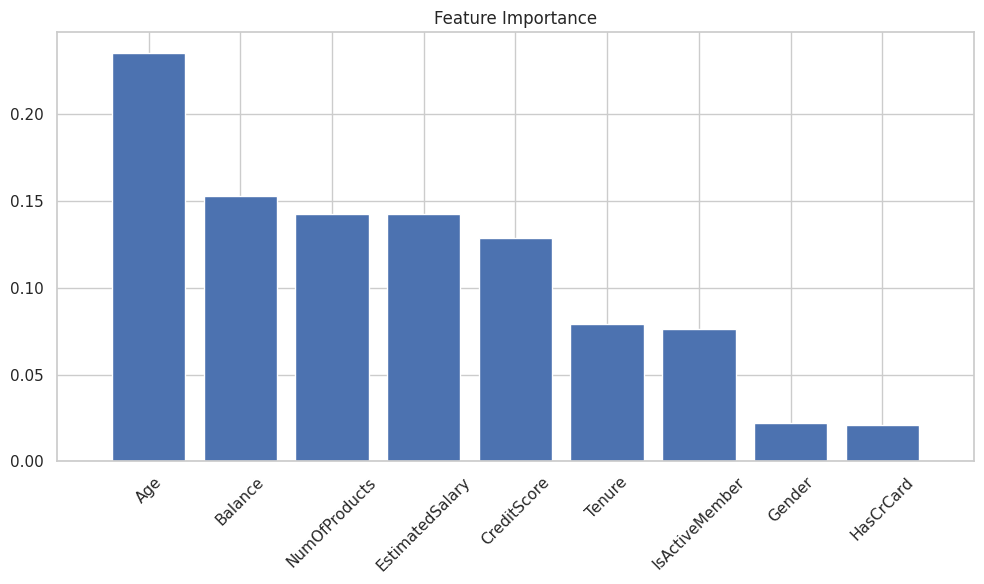

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# Set plot style for better aesthetics
sns.set(style="whitegrid")

class ChurnPredictionProject:
    def __init__(self):
        self.df = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.model = None
        self.scaler = StandardScaler()

    def generate_data(self, n_samples=2000):
        """
        Generates a synthetic telecom dataset for demonstration purposes.
        This ensures the code is runnable without needing an external CSV file.
        """
        print("Step 1: Generating synthetic dataset...")
        np.random.seed(42)

        # Feature generation
        data = {
            'CustomerID': range(1, n_samples + 1),
            'CreditScore': np.random.randint(350, 850, n_samples),
            'Gender': np.random.choice(['Male', 'Female'], n_samples),
            'Age': np.random.randint(18, 92, n_samples),
            'Tenure': np.random.randint(0, 10, n_samples),
            'Balance': np.random.uniform(0, 250000, n_samples),
            'NumOfProducts': np.random.randint(1, 5, n_samples),
            'HasCrCard': np.random.choice([0, 1], n_samples),
            'IsActiveMember': np.random.choice([0, 1], n_samples),
            'EstimatedSalary': np.random.uniform(10000, 200000, n_samples)
        }

        self.df = pd.DataFrame(data)

        # Creating a logic for 'Churn' so the model actually has a pattern to learn
        # Logic: Older people with low balance or inactive members are more likely to churn
        def churn_logic(row):
            score = 0
            if row['Age'] > 50: score += 2
            if row['IsActiveMember'] == 0: score += 1.5
            if row['Balance'] < 5000: score += 1
            if row['NumOfProducts'] > 3: score += 2 # Too many products often implies unhappiness

            # Add some randomness
            prob = 1 / (1 + np.exp(-(score - 3))) # Sigmoid roughly
            return 1 if np.random.random() < prob else 0

        self.df['Churn'] = self.df.apply(churn_logic, axis=1)

        print(f"Dataset generated with {self.df.shape[0]} rows and {self.df.shape[1]} columns.")
        print("-" * 30)

    def exploratory_data_analysis(self):
        """
        Performs basic EDA and saves/shows plots.
        """
        print("Step 2: Performing Exploratory Data Analysis (EDA)...")

        # 1. Churn Distribution
        plt.figure(figsize=(6, 4))
        sns.countplot(x='Churn', data=self.df, palette='viridis')
        plt.title('Distribution of Churn (Target Variable)')
        plt.show()

        # 2. Correlation Matrix
        plt.figure(figsize=(10, 8))
        # Select only numeric columns for correlation
        numeric_df = self.df.select_dtypes(include=[np.number])
        corr = numeric_df.corr()
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Feature Correlation Matrix')
        plt.show()

        # 3. Age vs Churn
        plt.figure(figsize=(10, 6))
        sns.histplot(data=self.df, x='Age', hue='Churn', multiple="stack", palette='magma')
        plt.title('Age Distribution by Churn Status')
        plt.show()

        print("EDA Visualizations displayed.")
        print("-" * 30)

    def preprocess_data(self):
        """
        Handles categorical variables and scaling.
        """
        print("Step 3: Preprocessing data...")

        # Drop irrelevant columns
        data = self.df.drop(['CustomerID'], axis=1)

        # Encoding Categorical Variables
        # Gender: Label Encoding (Male=1, Female=0 or similar)
        le = LabelEncoder()
        data['Gender'] = le.fit_transform(data['Gender'])

        # Define Features (X) and Target (y)
        X = data.drop('Churn', axis=1)
        y = data['Churn']

        # Split Data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Feature Scaling (Standardization)
        # It is important to scale numeric features for many algorithms
        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)

        print("Data preprocessed and split into Train/Test sets.")
        print("-" * 30)

    def train_model(self):
        """
        Trains a Random Forest Classifier.
        """
        print("Step 4: Training Random Forest Model...")

        self.model = RandomForestClassifier(n_estimators=100, random_state=42)
        self.model.fit(self.X_train, self.y_train)

        print("Model training complete.")
        print("-" * 30)

    def evaluate_model(self):
        """
        Evaluates the model and prints metrics.
        """
        print("Step 5: Evaluating Model...")

        y_pred = self.model.predict(self.X_test)
        y_prob = self.model.predict_proba(self.X_test)[:, 1]

        # 1. Classification Report
        print("\n--- Classification Report ---")
        print(classification_report(self.y_test, y_pred))

        # 2. Confusion Matrix
        plt.figure(figsize=(6, 5))
        cm = confusion_matrix(self.y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.title('Confusion Matrix')
        plt.show()

        # 3. ROC-AUC Score
        auc = roc_auc_score(self.y_test, y_prob)
        print(f"ROC-AUC Score: {auc:.4f}")

        # 4. Feature Importance
        feature_names = self.df.drop(['CustomerID', 'Churn'], axis=1).columns
        importances = self.model.feature_importances_
        indices = np.argsort(importances)[::-1]

        plt.figure(figsize=(10, 6))
        plt.title("Feature Importance")
        plt.bar(range(self.X_train.shape[1]), importances[indices], align="center")
        plt.xticks(range(self.X_train.shape[1]), feature_names[indices], rotation=45)
        plt.xlim([-1, self.X_train.shape[1]])
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    # Initialize and run the project pipeline
    project = ChurnPredictionProject()

    # Run steps
    project.generate_data()      # Generate synthetic data
    project.exploratory_data_analysis() # Visualize data
    project.preprocess_data()    # Clean and split
    project.train_model()        # Train Random Forest
    project.evaluate_model()     # Show results